In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart.csv")
df_clean = df.copy()
df_clean.loc[df_clean["chol"] == 0, "chol"] = np.nan
df_clean.loc[df_clean["trestbps"] ==0, "trestbps"] = np.nan



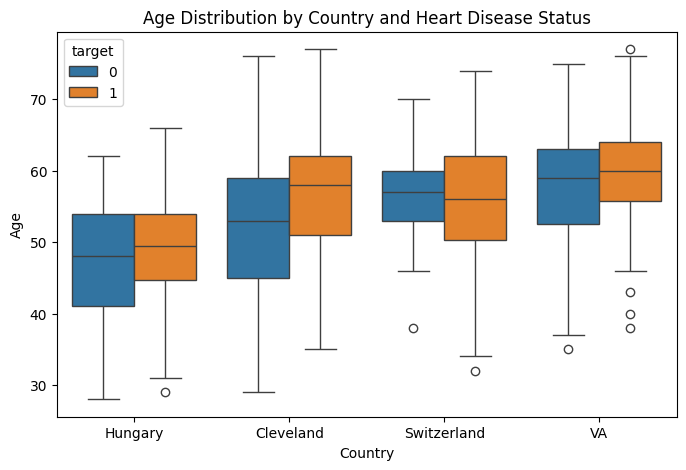

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="country", y="age", hue="target")
plt.title("Age Distribution by Country and Heart Disease Status")
plt.xlabel("Country")
plt.ylabel("Age")
plt.show()

## Age and Heart Disease Across Regions

- Across most regions, patients with heart disease tend to be older than patients without heart disease.
- This pattern suggests that age may be an important risk factor associated with heart disease.
- The VA population appears older overall compared to the other regions.
- Age differences between regions may partially explain differences in heart disease prevalence.

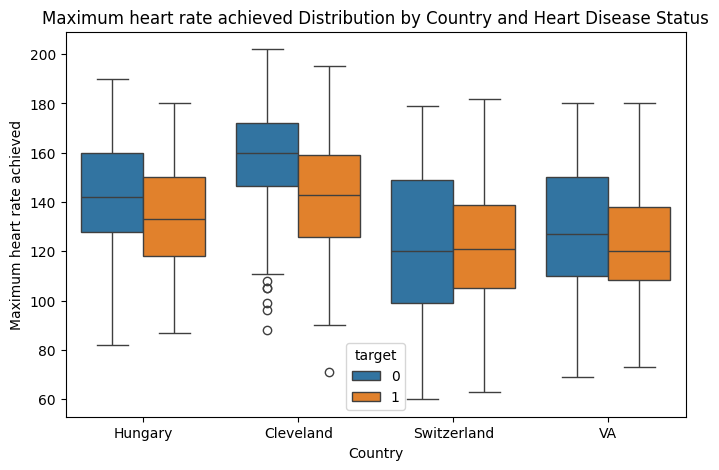

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="country", y="thalach", hue="target")
plt.title("Maximum heart rate achieved Distribution by Country and Heart Disease Status")
plt.xlabel("Country")
plt.ylabel("Maximum heart rate achieved")
plt.show()

We choosed thalach because it showed a moderate correlation with the target variable and is clinically relevant as an indicator of cardiovascular performance.

1. In Hungary, patients without heart disease tend to achieve higher maximum heart rates than patients with heart disease.
2. A similar pattern is observed in Cleveland, where higher maximum heart rates are associated with a lower prevalence of heart disease.
3. In Switzerland and VA, the relationship between maximum heart rate and heart disease appears weaker, as the distributions of both groups are highly overlapping.
4. The relationship between maximum heart rate and heart disease is not equally strong across all regions.

In [51]:
average_target = df.groupby("country")["target"].mean().reset_index()
average_target

,country,target
0,Cleveland,0.448845
1,Hungary,0.380952
2,Switzerland,0.861789
3,VA,0.740000


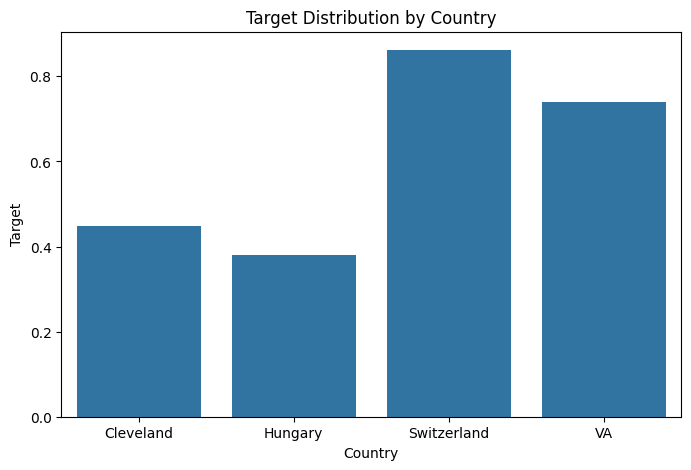

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=average_target, x = "country", y = "target")
plt.title("Target Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Target")
plt.show()

Switzerland and VA show substantially higher heart disease prevalence than Hungary and Cleveland. One possible explanation is that these populations are older on average. Since age is a known cardiovascular risk factor, the higher prevalence observed in these regions may be partially explained by differences in age distribution.

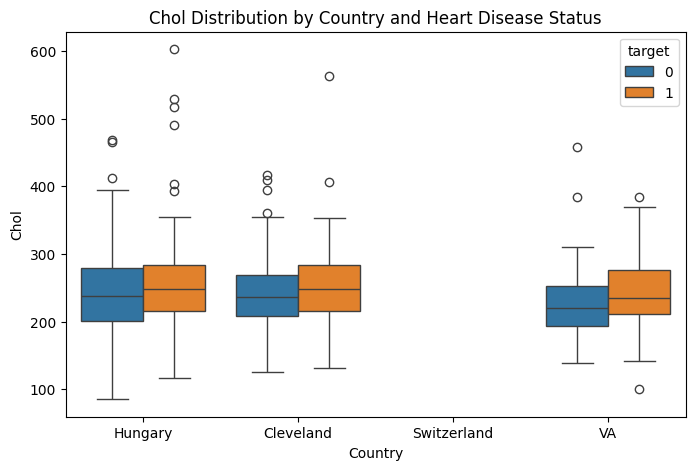

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x = "country", y = "chol", hue="target")
plt.title("Chol Distribution by Country and Heart Disease Status")
plt.xlabel("Country")
plt.ylabel("Chol")
plt.show()

Patients with heart disease tend to have slightly higher cholesterol levels across most regions. However, the distributions overlap considerably, suggesting that cholesterol alone may not clearly distinguish between patients with and without heart disease.

exang indicates whether the patient experienced exercise-induced chest pain. A value of 1 means that angina occurred during exercise, while 0 means it did not. Clinically, exercise-induced angina can be a warning sign of reduced blood flow to the heart.

In [54]:
df_clean["thal"].value_counts(dropna=False)

thal
NaN    486
3.0    196
7.0    192
6.0     46
Name: count, dtype: int64

The variable thal contains approximately 53% missing values, making it one of the most incomplete variables in the dataset.

In [55]:
df_clean.groupby("country")["thal"].apply(lambda x : x.isna().sum())

country
Cleveland        2
Hungary        266
Switzerland     52
VA             166
Name: thal, dtype: int64

Missing values in thal are heavily concentrated in specific regions, particularly Hungary and VA, suggesting that the missingness may be related to differences in data collection practices rather than random data loss.

In [56]:
pd.crosstab(df_clean["thal"], df_clean["target"], normalize="index")

target,0,1
thal,,
3.0,0.688776,0.311224
6.0,0.347826,0.652174
7.0,0.260417,0.739583


Among patients with available thal measurements, higher thal categories are associated with a substantially higher prevalence of heart disease. For example, approximately 74% of patients with thal = 7 have heart disease, compared to only 31% for thal = 3.
thal appears to be one of the strongest predictors of heart disease in the dataset. However, more than half of the observations are missing, so the findings should be interpreted with caution.

In [57]:
pd.crosstab(df_clean["exang"], df_clean["target"], normalize="index")

target,0,1
exang,,
0.0,0.596591,0.403409
1.0,0.246291,0.753709


Exercise-induced angina shows a strong association with heart disease. Approximately 75% of patients with exercise-induced angina were diagnosed with heart disease, compared to only 40% among patients without exercise-induced angina. Since the variable contains relatively few missing values, this finding appears robust.

In [58]:
df_clean["cp"].value_counts()

cp
4.0    496
3.0    204
2.0    174
1.0     46
Name: count, dtype: int64

In [59]:
pd.crosstab(df_clean["cp"], df_clean["target"], normalize="index")

target,0,1
cp,,
1.0,0.543478,0.456522
2.0,0.752874,0.247126
3.0,0.602941,0.397059
4.0,0.280242,0.719758


The relationship between chest pain type (cp) and heart disease is not monotonic. While patients with cp = 4 exhibit a markedly higher prevalence of heart disease (~72%), the other categories show lower and more variable disease rates. This suggests that certain chest pain types may be more strongly associated with heart disease than others.

In [60]:
df_clean["ca"].value_counts(dropna=False)

ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

In [61]:
df_clean.groupby("country")["ca"].apply(lambda x : x.isna().sum())

country
Cleveland        4
Hungary        291
Switzerland    118
VA             198
Name: ca, dtype: int64

Missing values in ca are highly concentrated outside Cleveland. Nearly all Cleveland patients have a recorded ca value, whereas the majority of observations from Hungary, VA, and Switzerland are missing. This suggests systematic differences in data collection across regions.

In [62]:
pd.crosstab(df_clean["ca"], df_clean["target"], normalize="index")

target,0,1
ca,,
0.0,0.696133,0.303867
1.0,0.417910,0.582090
2.0,0.243902,0.756098
3.0,0.250000,0.750000


The variable shows a strong association with heart disease; however, nearly two-thirds of the observations are missing, limiting the reliability and generalizability of this finding.

In [63]:
df_clean["oldpeak"].describe()

count    858.000000
mean       0.878788
std        1.091226
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

<Axes: xlabel='country', ylabel='oldpeak'>

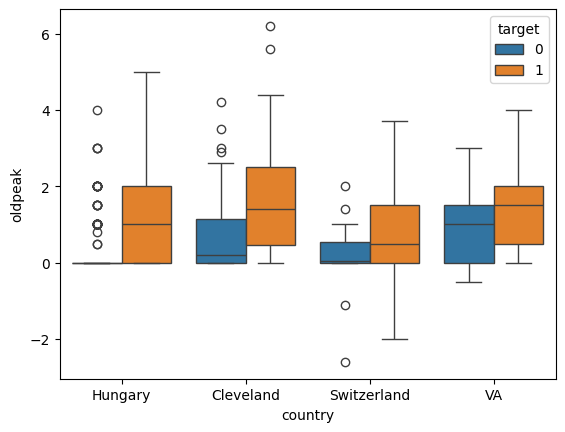

In [64]:
sns.boxplot(data=df_clean, x= "country", y = "oldpeak", hue= "target")

Patients with heart disease generally exhibit higher oldpeak values, particularly in Cleveland and Switzerland. The relationship is less pronounced in Hungary and VA, where the distributions overlap more substantially. Despite a small number of negative values and approximately 7% missing observations, oldpeak appears to be a clinically relevant indicator of heart disease.